In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, convolve, find_peaks
from scipy.fft import fft, ifft
from glob import glob
import functions as ft
from natsort import natsorted
import re

%matplotlib widget

In [2]:
data_array = np.loadtxt(r'C:\Users\wilbertr\ownCloud2\PhD\PhD\Data analysis\MIR\SuperKIDs_1_5THz_individualKIDparameters.csv', delimiter=',', skiprows=1)
f0_design = data_array[:, 3]
f0_design.shape
# np.save('LT218_27f0s_design.npy', f0_design)

(27,)

Total:  27
Sufficiently spaced with  0.6 MHz:  25


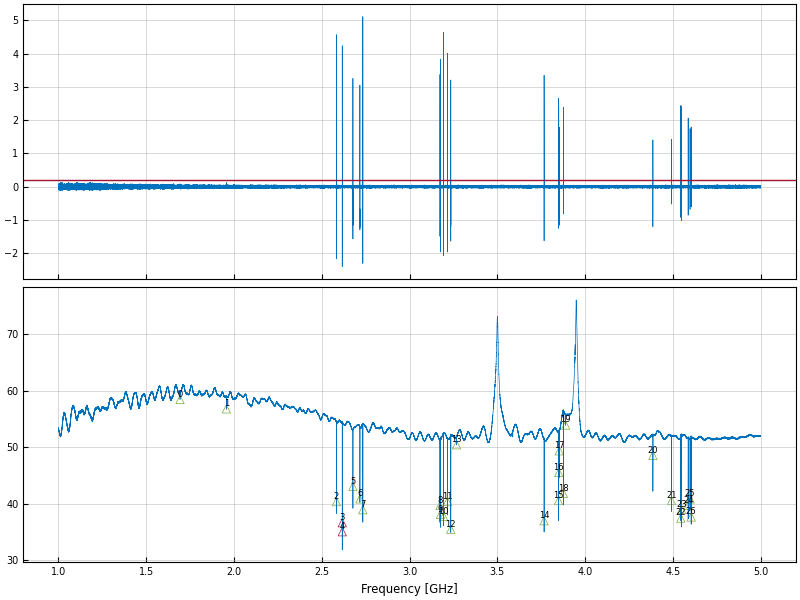

In [34]:
sweeps = glob(r'Z:\KIDonSun\experiments\Entropy ADR\LT218Chip1_BF_20240820_dark\Single tone\VNAsweep*.dat')[1:]
freqs = []
s21 = []
for sweep in sweeps:
    with open(sweep, 'r') as f:
        data_array = np.loadtxt(f, delimiter='\t')
    freqs.append(data_array[:, 0])
    s21.append(data_array[:, 1])
freqs = np.hstack(freqs)[:-2]
s21 = np.hstack(s21)[:-2]
# fig, ax = plt.subplots()
# ax.plot(s21)
s21[256040:] += s21[256039] - s21[256040]


sw = 3 # odd number
mph = 0.2
min_df = 0.0006
window = np.ones(sw)/sw
smooth_s21 = convolve(s21, window, mode='valid')
ds21 = np.diff(smooth_s21, 1)
smooth_ds21 = convolve(ds21, window, mode='valid')
d2s21 = np.diff(smooth_ds21, 1)

locs, _ = find_peaks(d2s21, height=mph, prominence=mph)
# locs = np.delete(locs, 6)  # Deleting the 6th element (index 5)
locs = np.append(locs, [88688, 122463, 290308, 369794])
locs.sort()
locs += 1
f0s = freqs[locs]
heights = smooth_s21[locs]

df0s = f0s[1:] - f0s[:-1]
df_mask = np.zeros(f0s.shape, dtype=bool)
too_close = df0s < min_df
too_close_mask = np.hstack((False, too_close)) + np.hstack((too_close, False))

s21_mins = smooth_s21[locs]
fig, ax = plt.subplot_mosaic('a;b', sharex=True, figsize=(8, 6), constrained_layout=True)
ax['a'].plot(freqs[:len(d2s21)], d2s21, lw=.5)
ax['b'].plot(freqs[:len(smooth_s21)], smooth_s21, lw=.5)
# ax['b'].plot(smooth_s21, lw=.5)
ax['a'].axhline(mph, c='r')

# ax['a'].scatter(freqs[locs[~too_close_mask]], heights[~too_close_mask], marker='v', c='None', edgecolor='g')
ax['b'].scatter(f0s[~too_close_mask], s21_mins[~too_close_mask], marker='^', c='None', edgecolor='g')
# ax['a'].scatter(freqs[locs[too_close_mask]], heights[too_close_mask], marker='v', c='None', edgecolor='r')
ax['b'].scatter(f0s[too_close_mask], s21_mins[too_close_mask], marker='^', c='None', edgecolor='r')
for i, loc in enumerate(locs):
    ax['b'].annotate(f'{i}', (f0s[i], s21_mins[i]-2), textcoords="offset points", xytext=(0,10), ha='center', fontsize=6)
ax['b'].set_xlabel('Frequency [GHz]')
print('Total: ', len(locs))
print('Sufficiently spaced with ', min_df*1e3 , 'MHz: ', len(locs[~too_close_mask]))
# np.save('LT218_27f0s_from_VNA.npy', f0s)

np.float64(0.06327441776759907)

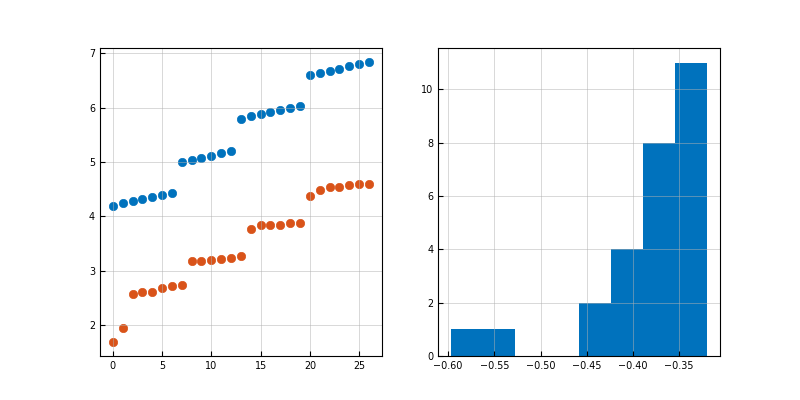

In [4]:
fig, axes = plt.subplot_mosaic('ab', figsize=(8,4))
ax = axes['a']
x = np.arange(27)
ax.scatter(x, f0_design)
ax.scatter(x, f0s)
ax = axes['b']
df_f = (f0s - f0_design )/f0_design
ax.hist(df_f, bins='auto')
np.std(df_f)

In [25]:
dir = r'Z:\KIDonSun\experiments\Entropy ADR\LT218Chip1_BF_20240820_dark\Single tone\TD_Power/'
info_files = natsorted(glob(dir + '*TDvis0*_info.dat'))
print(info_files)
print(len(info_files))

['Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID8_116dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID8_118dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID9_116dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID9_118dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID10_115dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID10_117dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single tone\\TD_Power\\KID12_118dBm__TDvis0_TmK100_info.dat', 'Z:\\KIDonSun\\experiments\\Entropy ADR\\LT218Chip1_BF_20240820_dark\\Single to

In [31]:
kid_table = np.zeros(27)
f0s = np.load(r'D:\Data\LT218_MUX\LT218_27f0s_from_VNA.npy')
for file in info_files:
    id = int(re.findall('KID\d+', file)[0][3:])
    f0_meas = ft.get_info(file)[0]
    id_main = np.argmin(np.absolute(f0_meas - f0s))
    kid_table[id_main] = id

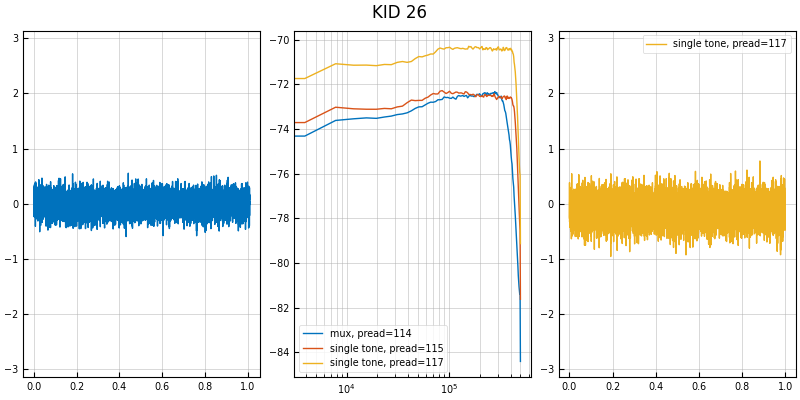

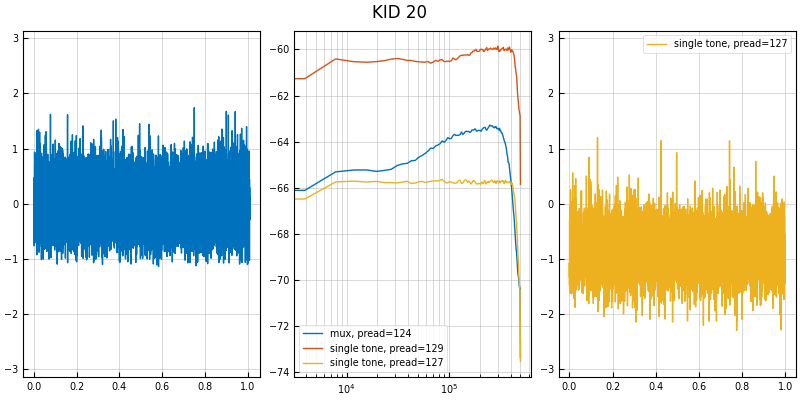

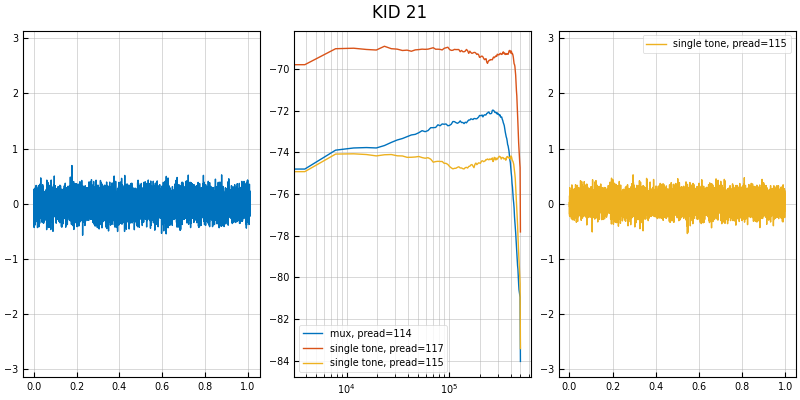

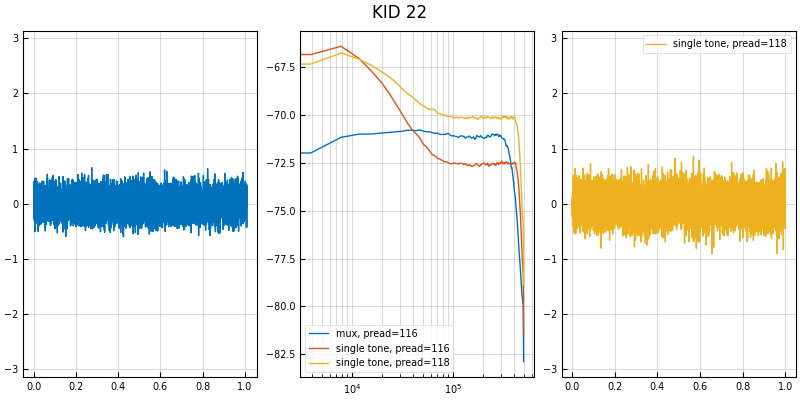

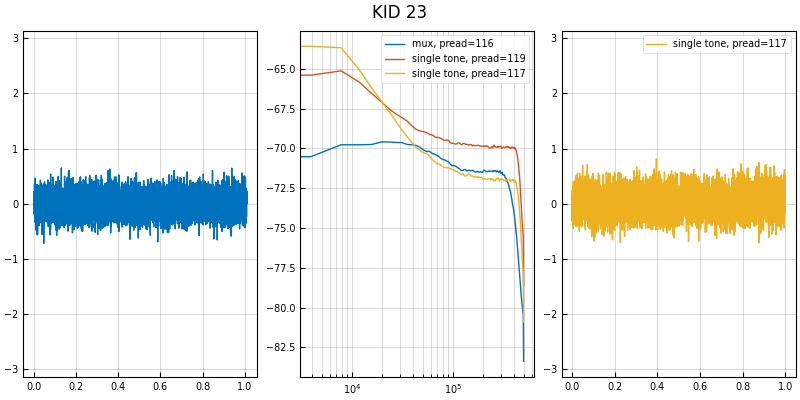

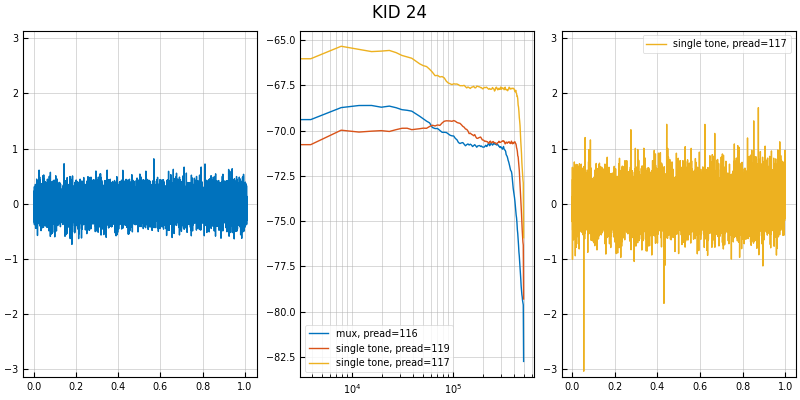

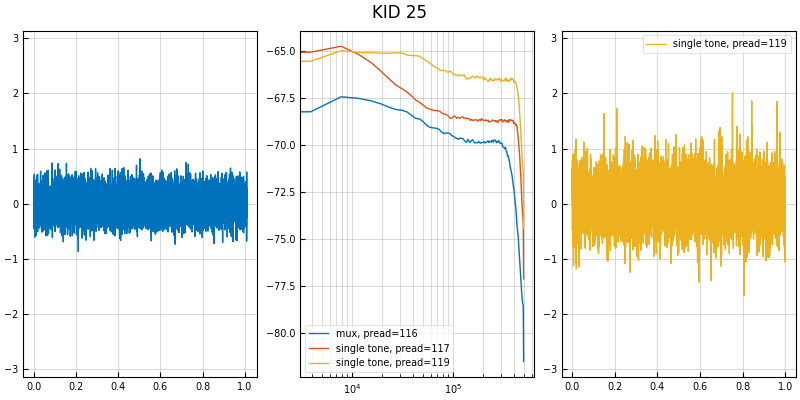

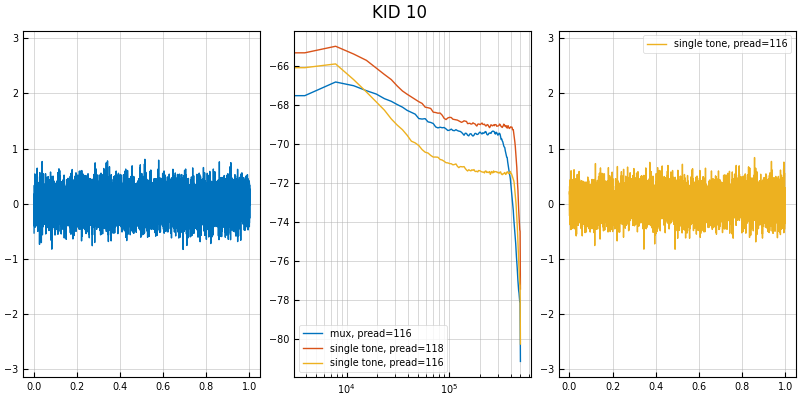

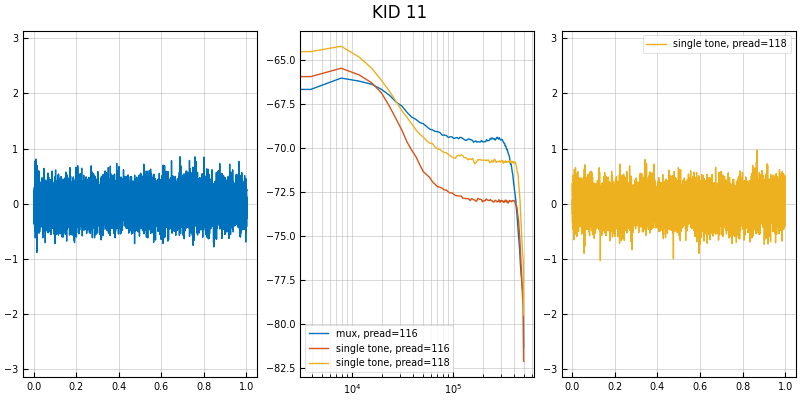

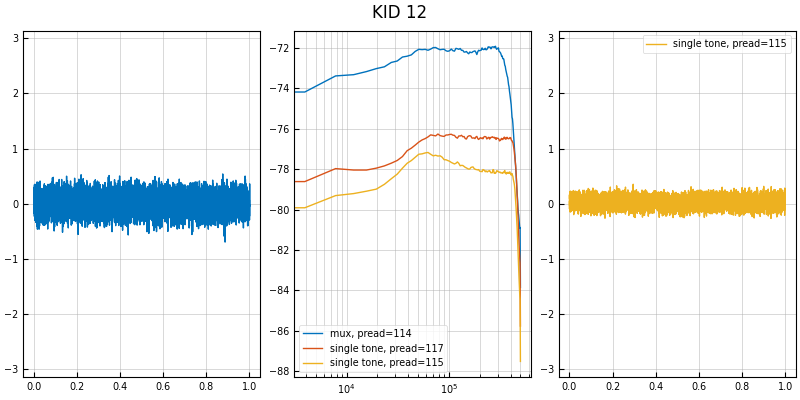

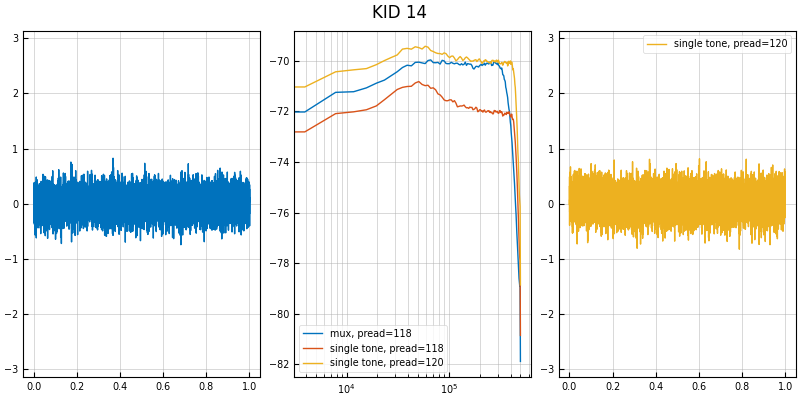

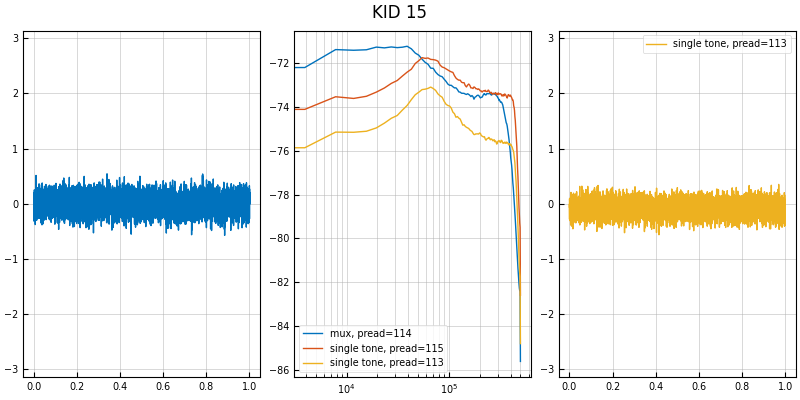

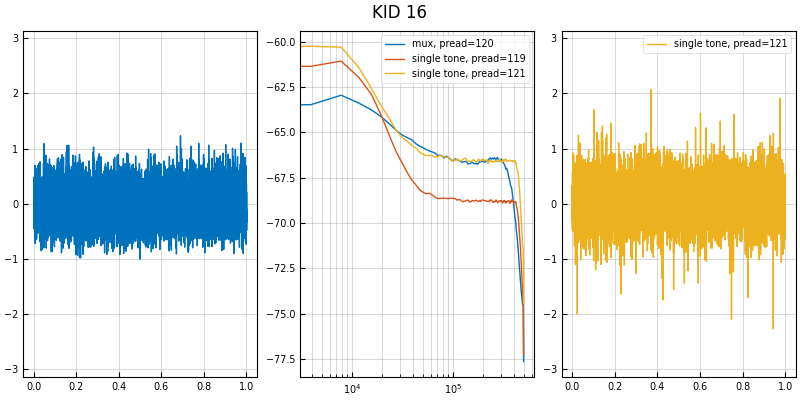

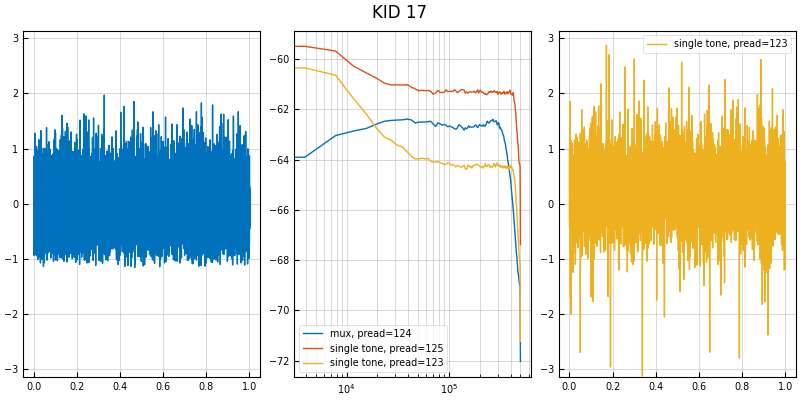

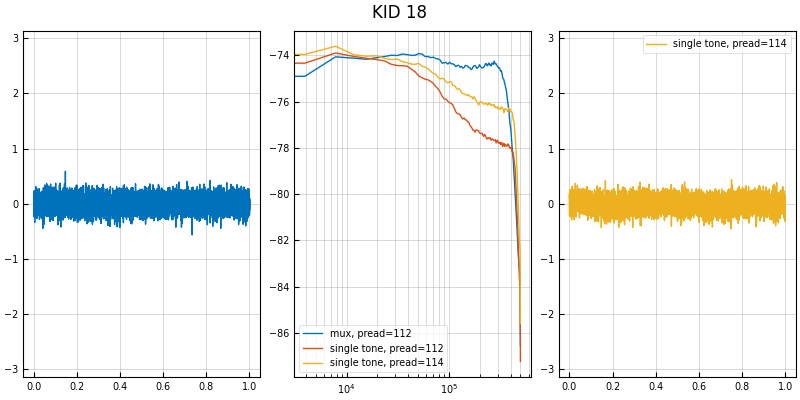

In [33]:
mux_files = glob(r'D:\Data\LT218_MUX\Processed data\*1s.npy')
st_powers = []
for mux_file in mux_files:
    t_mux, amp_mux, phase_mux = np.load(mux_file)
    name_mux = mux_file.split('\\')[-1]
    kid_id = int(re.findall('KID\d+', name_mux)[0][3:])
    pread_mux = int(re.findall('\d+dBm', name_mux)[0][:-3])
    phase_mux -= np.mean(phase_mux)
    fig, axes = plt.subplot_mosaic('abc', figsize=(8,4), constrained_layout=True)
    ax = axes['a']
    ax.plot(t_mux[::100], phase_mux[::100])
    ax.set_ylim([-np.pi, np.pi])
    ax = axes['b']
    freqs_mux, Nxx_mux = welch(phase_mux, fs=1e6) 
    ax.semilogx(freqs_mux, 10*np.log10(Nxx_mux), label='mux, pread=%d' % (pread_mux))

    dir = r'Z:\KIDonSun\experiments\Entropy ADR\LT218Chip1_BF_20240820_dark\Single tone\TD_Power/'
    st_kid_id = kid_table[kid_id]
    st_files = glob(dir + 'KID%d*TDvis0_*.bin' % (st_kid_id))
    for st_file in st_files:
        pread = int(re.findall('\d+dBm', st_file)[0][:-3])
        _, phase, _ = ft.get_data([st_file])

        freqs, Nxx = welch(phase, fs=1e6) 
        ax.semilogx(freqs, 10*np.log10(Nxx), label='single tone, pread=%d' % (pread))
    ax.legend()
    ax = axes['c']
    ax.plot(np.arange(len(phase))[::100]/1e6, phase[::100], c='y', label='single tone, pread=%d' % (pread))
    ax.set_ylim([-np.pi, np.pi])
    ax.legend()

    fig.suptitle(f'KID {kid_id}')


In [5]:
mux_files = glob(r'D:\Data\LT218_MUX\8KIDs_1s\*.npy')
st_powers = []
for mux_file in mux_files:
    t_mux, amp_mux, phase_mux = np.load(mux_file)
    name_mux = mux_file.split('\\')[-1]
    kid_id = int(re.findall('KID\d+', name_mux)[0][3:])
    pread_mux = int(re.findall('\d+dBm', name_mux)[0][:-3])
    phase_mux -= np.mean(phase_mux)
    fig, axes = plt.subplot_mosaic('abc', figsize=(8,4), constrained_layout=True)
    ax = axes['a']
    ax.plot(t_mux[::100], phase_mux[::100])
    ax.set_ylim([-np.pi, np.pi])
    ax = axes['b']
    freqs_mux, Nxx_mux = welch(phase_mux, fs=1e6) 
    ax.semilogx(freqs_mux, 10*np.log10(Nxx_mux), label='mux, pread=%d' % (pread_mux))

    st_files = glob(r'Z:\KIDonSun\experiments\Entropy ADR\LT218Chip1_BF_20240820_dark\Single tone\TD_Power\KID%d*TDvis0_*.bin' % (kid_id))
    for st_file in st_files:
        pread = int(re.findall('\d+dBm', st_file)[0][:-3])
        _, phase, _ = ft.get_data([st_file])

        freqs, Nxx = welch(phase, fs=1e6) 
        ax.semilogx(freqs, 10*np.log10(Nxx), label='single tone, pread=%d' % (pread))
    ax.legend()
    ax = axes['c']
    ax.plot(np.arange(len(phase))[::100]/1e6, phase[::100], c='y', label='single tone, pread=%d' % (pread))
    ax.set_ylim([-np.pi, np.pi])
    ax.legend()

    fig.suptitle(f'KID {kid_id}')

In [52]:
file = glob(r'D:\Data\LT218_MUX\1KID_100s\*.npy')[0]
[ts, phase, amp] = np.load(file)

In [101]:
filter_type = 'exp'
sw = 300
mph = 5
mpp = mph
pw = 1400
pw_offset= 100
sff = 1e6

signal = phase
signal -= np.mean(signal)
exp_filter = ft.get_window(filter_type, sw)
std = ft.get_sigma(signal[:100000], exp_filter)
ph = mph*std
pp = mpp*std
locs, props = ft.find_pks(signal, ph, pp, exp_filter)
args = np.arange(len(locs))
pulses, single_idx = ft.get_single_pulses(signal, locs, pw, pw_offset, args)


In [102]:
pulse_template = np.mean(pulses, axis=0)

In [103]:
noise_locs, _ = ft.find_pks(signal[:100000], ph, pp, exp_filter)
noises = ft.get_single_noises(signal[:100000], noise_locs, pw+pw_offset)
_, noise_psd = ft.get_avg_psd(noises, pw+pw_offset, sff, exclude_dc=False, onesided=False)

In [ ]:
opt_filter = ft.opt_filter(pulse_template, noise_psd, exclude_dc=False).real
opt_filter /= np.sum(opt_filter)
H_opt, R_sn, _, _ = ft.optimal_filter(pulses, pulse_template, sff*1e6, 1, noise_psd)
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
ax.plot(opt_filter)

In [ ]:
print(locs.shape, len(locs)/1000)

In [ ]:
# fig, ax = plt.subplots()
# ax.plot(signal[::10000], zorder=0)
# ax.plot(convolve(signal, exp_filter, mode='valid')[::10000], c='o', zorder=1)
# ax.axhline(mpp*std, color='r', zorder=2)

In [ ]:
fig, axes = plt.subplot_mosaic('abc')
binsize = 0.01
bins=np.arange(-.5, 3, binsize)
ax = axes['a']
ax.plot(pulses.T, lw=0.1, c='b')
ax = axes['b']
ax.plot(pulse_template)
ax = axes['c']
_ = ax.hist(H_opt, bins=bins)
_ = ax.hist(convolve(noises.flatten(), opt_filter, mode='valid'), bins=bins, facecolor='gray', label='Noise', zorder=0)
ax.set_ylim([0, 500])
